<div style="background-color:#5A3516; color:#F3EEE6; padding:22px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h1 style="color:#F3EEE6; margin-bottom:0;"><b>Machine Learning II — Customer Segmentation</b></h1>
<h3 style="color:#D8C0B4; margin-top:6px;">Notebook 5 — Association Rules per Segment</h3>
<p style="color:#D8C0B4; font-size:15px; margin-top:14px;">This notebook uses the final customer segments to identify co purchase patterns and translate them into practical campaign suggestions.</p>
</div>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
Association rules are mined after the segmentation stage. The clusters are not refitted here; they are used as business groups to compare basket patterns. This keeps the workflow consistent: clustering defines the customer segments, while association rules explain which product combinations are most relevant inside each segment.
</div>

<div style="background-color:#5A3516; color:#F3EEE6; padding:18px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin-top:0;"><b>Index</b></h2>
<ol>
<li>Imports and data loading</li>
<li>Transaction preparation per segment</li>
<li>Apriori parameters</li>
<li>Association rules per segment</li>
<li>Top rules summary</li>
<li>Rule robustness check</li>
<li>Campaign suggestions</li>
<li>Final interpretation</li>
</ol>
</div>

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>1) Imports and data loading</b></h2>
</div>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Why rules are mined after segmentation.</b><br><br>
The association rules are not used to create the clusters. They are used after segmentation to understand which products tend to appear together inside each customer group. This keeps the workflow clear: clustering defines the customer profiles, and basket rules make those profiles more actionable.
</div>

In [1]:
import warnings
from pathlib import Path

import pandas as pd
import seaborn as sns

import utils_association_rules as uar
from utils_cluster_characterization import CLUSTER_NAMES

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

DATA_DIR = Path("../datasets")

PROJECT_PALETTE = ['#B87540', '#B2543D', '#7E6A43', '#A8B7BA', '#D8C0B4', '#C8AB8C', '#5A3516', '#B98F70']
sns.set_theme(style='whitegrid', palette=PROJECT_PALETTE)

In [2]:
df = uar.load_segment_transactions(DATA_DIR, CLUSTER_NAMES)
uar.transaction_overview(df)

Transactions: 100,000
Customers with cluster: 28,127
Unique items: 164

Transactions per cluster:


,transactions
cluster,
0,17733
1,10833
2,12312
3,13276
4,9888
5,8198
6,17362
7,10398


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
The basket data is checked before mining rules. Duplicate invoices would distort support and confidence, while extremely dominant items could generate rules that are statistically frequent but not very useful for campaign design.
</div>

In [3]:
basket_quality, top_items = uar.basket_quality_summary(DATA_DIR)
display(basket_quality)
display(top_items)

,basket_rows,unique_invoices,duplicated_invoice_rows,unique_customers,duplicated_invoice_customer_rows
0,100000,100000,0,28127,0


,item,transaction_support_%
0,asparagus,12.81
1,airpods,12.14
2,cereals,9.95
3,fresh bread,9.93
4,butter,9.65
5,eggs,9.24
6,protein bar,8.70
7,cooking oil,8.62
8,toilet paper,8.40
9,babies food,8.32


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
The basket file contains unique invoice identifiers, so no transaction level deduplication is required before rule mining. The most frequent products are also inspected to check whether a small set of generic items dominates the baskets. Since no item appears in an excessively large share of transactions, the rules are kept on the full product list.
</div>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
Before mining rules, the basket file is checked against the final segmentation file. This confirms how many customers from each segment have basket information and prevents interpreting association rules for segments with weak transaction coverage.
</div>

In [4]:
basket_coverage = uar.basket_coverage_by_segment(DATA_DIR, CLUSTER_NAMES)
display(basket_coverage)

Basket rows: 100,000
Customers in final segmentation: 33,038
Segmented customers with basket data: 28,127


,cluster,segment,segment_customers,customers_with_basket,coverage_%,transactions
0,0,Regulars,6365,5361,84.23,17733
1,1,Families,3662,3131,85.50,10833
2,2,Economizers,5062,4218,83.33,12312
3,3,Vegetarians,3740,3277,87.62,13276
4,4,Loyalists,3393,2905,85.62,9888
5,5,Techies,3199,2688,84.03,8198
6,6,Wellness,3323,3019,90.85,17362
7,7,Promoters,4294,3528,82.16,10398


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>2) Transaction preparation per segment</b></h2>
</div>

In [5]:
cluster_transactions = uar.transactions_by_cluster(df)
transaction_summary = uar.show_transactions_by_cluster(df, CLUSTER_NAMES)

,cluster,segment,transactions
0,0,Regulars,17733
1,1,Families,10833
2,2,Economizers,12312
3,3,Vegetarians,13276
4,4,Loyalists,9888
5,5,Techies,8198
6,6,Wellness,17362
7,7,Promoters,10398


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>3) Apriori parameters</b></h2>
</div>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Why the same thresholds are used across segments.</b><br><br>
The same support, confidence and lift thresholds are applied to every segment so that the results are comparable. The thresholds are intentionally moderate because some segments have fewer transactions and very strict values would remove their rules entirely. Differences between segments are therefore interpreted using both rule strength and the overlap check below.
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
The Apriori thresholds are fixed before interpreting the final rules. A minimum support of <b>1%</b> is used because rules are mined separately inside each segment, so each model has fewer transactions than the full basket dataset. A minimum confidence of <b>20%</b> keeps conditional relationships that are still interpretable at segment level, while a lift threshold above <b>1.2</b> ensures that the association is stronger than random co occurrence.
</div>


In [6]:
MIN_SUPPORT = 0.01
MIN_CONFIDENCE = 0.20
MIN_LIFT = 1.2
TOP_N_RULES = 5

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>4) Association rules per segment</b></h2>
</div>

In [7]:
all_rules = uar.mine_rules_per_segment(
    df,
    CLUSTER_NAMES,
    min_support=MIN_SUPPORT,
    min_confidence=MIN_CONFIDENCE,
    min_lift=MIN_LIFT,
)


--- Cluster 0: Regulars (17,733 transactions) ---
  Frequent itemsets: 249
  Rules returned: 58

--- Cluster 1: Families (10,833 transactions) ---
  Frequent itemsets: 1,243
  Rules returned: 533

--- Cluster 2: Economizers (12,312 transactions) ---
  Frequent itemsets: 512
  Rules returned: 487

--- Cluster 3: Vegetarians (13,276 transactions) ---
  Frequent itemsets: 997
  Rules returned: 382

--- Cluster 4: Loyalists (9,888 transactions) ---
  Frequent itemsets: 260
  Rules returned: 8

--- Cluster 5: Techies (8,198 transactions) ---
  Frequent itemsets: 1,816
  Rules returned: 4,023

--- Cluster 6: Wellness (17,362 transactions) ---
  Frequent itemsets: 178
  Rules returned: 4

--- Cluster 7: Promoters (10,398 transactions) ---
  Frequent itemsets: 440
  Rules returned: 330


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>5) Top rules per segment</b></h2>
</div>

In [8]:
uar.display_top_rules(all_rules, CLUSTER_NAMES, n=TOP_N_RULES)


=== Cluster 0: Regulars ===


,antecedents,consequents,support,confidence,lift
0,"airpods, energy drink",bluetooth headphones,0.014,0.370,3.716
1,"airpods, bluetooth headphones",energy drink,0.014,0.367,3.606
2,"bluetooth headphones, energy drink",airpods,0.014,0.553,3.306
3,bluetooth headphones,energy drink,0.025,0.248,2.435
4,energy drink,bluetooth headphones,0.025,0.243,2.435



=== Cluster 1: Families ===


,antecedents,consequents,support,confidence,lift
0,"cereals, chocolate bread","eggs, fresh bread",0.012,0.211,1.584
1,"black tea, fresh bread",salt,0.012,0.219,1.561
2,"milk, oatmeal","cereals, eggs",0.010,0.217,1.504
3,"cereals, tea","butter, eggs",0.017,0.202,1.478
4,"eggs, salt","cereals, fresh bread",0.011,0.209,1.475



=== Cluster 2: Economizers ===


...

,antecedents,consequents,support,confidence,lift
0,bluetooth headphones,"airpods, energy drink",0.014,0.202,5.506
1,"airpods, energy drink",bluetooth headphones,0.014,0.372,5.506
2,"bluetooth headphones, energy drink",airpods,0.014,0.629,5.087
3,"airpods, bluetooth headphones",energy drink,0.014,0.419,4.850
4,"airpods, energy bar",bluetooth headphones,0.010,0.323,4.777



=== Cluster 6: Wellness ===


,antecedents,consequents,support,confidence,lift
0,energy drink,airpods,0.017,0.245,2.346
1,bluetooth headphones,airpods,0.016,0.223,2.135
2,pancakes,airpods,0.011,0.212,2.028
3,energy bar,airpods,0.011,0.211,2.020



=== Cluster 7: Promoters ===


,antecedents,consequents,support,confidence,lift
0,"salad, tomatoes","asparagus, carrots",0.010,0.301,5.799
1,"carrots, salad","asparagus, tomatoes",0.010,0.298,5.755
2,"carrots, tomatoes","asparagus, salad",0.010,0.302,5.699
3,"airpods, protein bar",energy drink,0.011,0.444,5.014
4,"airpods, energy drink",bluetooth headphones,0.017,0.420,4.681


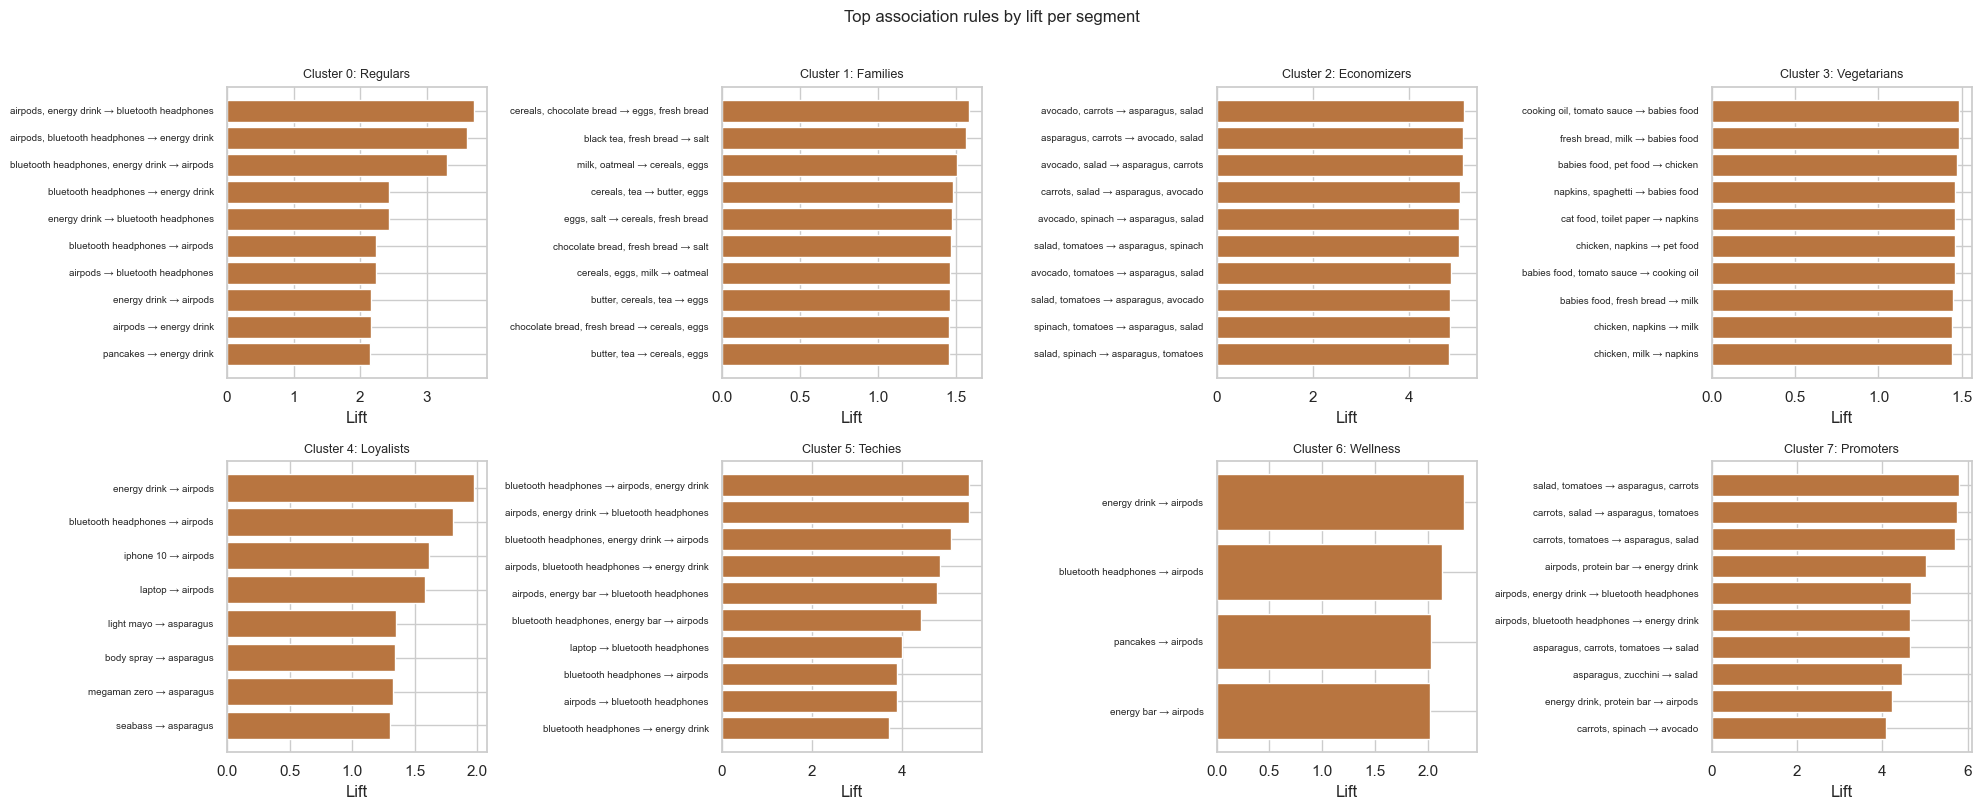

In [9]:
uar.plot_rules_by_segment(all_rules, CLUSTER_NAMES, n=10)

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Rule overlap check.</b><br><br>
Some product relationships are expected to appear in more than one segment because association rules are mined from baskets, not from the clustering variables themselves. For example, technology accessory rules can be frequent across several customer groups. The table below checks whether each segment has mostly generic rules or more segment specific basket patterns.
<br><br>
Generic rules are not wrong, but they should be interpreted as broad cross sell opportunities rather than as strong evidence that one segment is unique.
</div>

In [10]:
rule_overlap = uar.rule_overlap_summary(all_rules, CLUSTER_NAMES, n=10)
display(rule_overlap)

,cluster,segment,top_rules_checked,unique_consequents,repeated_exact_rules,repeated_consequents,main_consequents,interpretation
0,0,Regulars,10,3,7,10,energy drink; bluetooth headphones; airpods,mostly generic
1,1,Families,10,7,0,0,"cereals, eggs; salt; eggs, fresh bread",more segment specific
2,2,Economizers,10,6,0,6,"asparagus, salad; asparagus, avocado; avocado, salad",shared product theme
3,3,Vegetarians,10,6,0,0,babies food; napkins; milk,more segment specific
4,4,Loyalists,8,2,2,4,airpods; asparagus,shared product theme
5,5,Techies,10,4,6,9,bluetooth headphones; airpods; energy drink,mostly generic
6,6,Wellness,4,1,2,4,airpods,mostly generic
7,7,Promoters,10,8,2,7,"energy drink; salad; asparagus, carrots",shared product theme


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>6) Rule robustness check</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">Association rules can be unstable: a rule that appears strong on the full dataset may not hold on unseen transactions. This section splits each segment's transactions into a training set (80%) and a test set (20%), mines rules on the training split, and checks whether the same rules appear in the test split and whether their lift is consistent. A low mean lift difference indicates that the rule generalises beyond the training transactions.</p>
</div>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
The robustness table reports, for each segment: the number of rules found on the training split, the number found on the test split, the number of rules that appear in both splits (matched rules), and the mean relative lift difference between the two splits. A high number of matched rules with a low lift difference means the rules are stable and not artefacts of the specific transactions seen during mining.
</div>

In [11]:
robustness = uar.compare_train_test_rules(
    df,
    CLUSTER_NAMES,
    min_support=MIN_SUPPORT,
    min_confidence=MIN_CONFIDENCE,
    min_lift=MIN_LIFT,
    test_size=0.20,
    random_state=42,
)
display(robustness)

,cluster,segment,train_rules,test_rules,matched_rules,mean_lift_difference_%
0,0,Regulars,57,61,48,7.47
1,1,Families,540,1067,234,7.62
2,2,Economizers,506,467,394,8.23
3,3,Vegetarians,379,469,186,7.56
4,4,Loyalists,8,26,5,14.96
5,5,Techies,4117,3660,2793,10.81
6,6,Wellness,4,1,1,1.18
7,7,Promoters,344,382,274,9.26


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>How to read this table.</b><br><br>
A segment with many matched rules and a low mean lift difference has stable co purchase patterns. Segments with few or no matched rules should be interpreted with caution: the rules may reflect narrow basket behaviour or limited transaction evidence rather than a strong segment specific pattern.
<br><br>
This robustness check is read together with the overlap table. A stable rule can still be generic if it appears in several segments; in that case it is useful for broad cross selling, but less useful for differentiating one segment from another.
</div>


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>7) Campaign suggestions</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">Each rule is translated into a simple campaign logic: when a customer from a given segment buys the antecedent item set, the consequent item set becomes a candidate recommendation or promotion.</p>
</div>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>From rules to campaign ideas.</b><br><br>
The campaign suggestions are intentionally simple. They translate the strongest rules into possible product triggers, but they should be interpreted as starting points for marketing actions rather than automatic promotions.
<br><br>
Before creating the final campaign table, recommendations that contradict a segment profile are excluded. For example, meat or fish products are not promoted to the Vegetarians segment, even if a statistical association appears in the basket data. This keeps the campaign logic consistent with the business interpretation of each segment.
</div>


In [12]:
EXCLUDED_RECOMMENDATIONS = {
    0: ["chicken", "meat", "fish"],
}

campaigns = uar.build_campaign_table(
    all_rules,
    CLUSTER_NAMES,
    n=3,
    excluded_recommendations=EXCLUDED_RECOMMENDATIONS,
)
display(campaigns)


,cluster,segment,if_buys,promote,confidence,lift
0,0,Regulars,"airpods, energy drink",bluetooth headphones,0.37,3.72
1,0,Regulars,"airpods, bluetooth headphones",energy drink,0.37,3.61
2,0,Regulars,"bluetooth headphones, energy drink",airpods,0.55,3.31
3,1,Families,"cereals, chocolate bread","eggs, fresh bread",0.21,1.58
4,1,Families,"black tea, fresh bread",salt,0.22,1.56
5,1,Families,"milk, oatmeal","cereals, eggs",0.22,1.50
6,2,Economizers,"avocado, carrots","asparagus, salad",0.32,5.14
7,2,Economizers,"asparagus, carrots","avocado, salad",0.20,5.11
8,2,Economizers,"avocado, salad","asparagus, carrots",0.30,5.11
9,3,Vegetarians,"cooking oil, tomato sauce",babies food,0.42,1.48


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>How to read the campaign table.</b><br><br>
Each row is a promotion trigger. The <i>if_buys</i> column contains the basket items that activate the rule, and the <i>promote</i> column contains the suggested product or product set. Confidence measures how often the promoted item appears after the trigger items. Lift above 1 means that the association is stronger than chance, so higher lift indicates a more segment specific opportunity.
</div>

In [13]:
uar.export_campaign_table(campaigns, DATA_DIR)

Saved segment_campaign_rules.csv
Total campaign suggestions: 24


'../datasets/segment_campaign_rules.csv'

### 7.1 - Creative campaign texts

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
The campaign table is converted into ready-to-use promotional texts with a discount level derived from the rule lift. Higher lift rules receive higher discounts.
</div>

In [15]:
creative = uar.format_campaign_creative(campaigns, cluster_names=CLUSTER_NAMES)
uar.print_campaign_report(creative)
display(creative[["segment", "if_buys", "promote", "discount_%", "campaign_text"]].head(20))


  Segment: Economizers

  Campaign 1:
  ➤  Buy Avocado, Carrots and get 30% off Asparagus, Salad!
     (Rule lift 5.14 — customers who buy Avocado, Carrots are 5.1× more likely than average to also buy Asparagus, Salad (confidence 32%).)

  Campaign 2:
  ➤  Buy Asparagus, Carrots and get 30% off Avocado, Salad!
     (Rule lift 5.11 — customers who buy Asparagus, Carrots are 5.1× more likely than average to also buy Avocado, Salad (confidence 20%).)

  Campaign 3:
  ➤  Buy Avocado, Salad and get 30% off Asparagus, Carrots!
     (Rule lift 5.11 — customers who buy Avocado, Salad are 5.1× more likely than average to also buy Asparagus, Carrots (confidence 30%).)

  Segment: Families

  Campaign 1:
  ➤  Love Cereals, Chocolate Bread? You'll love Eggs, Fresh Bread too — 15% off just for you.
     (Rule lift 1.58 — customers who buy Cereals, Chocolate Bread are 1.6× more likely than average to also buy Eggs, Fresh Bread (confidence 21%).)

  Campaign 2:
  ➤  Buy Black Tea, Fresh Bread and g

,segment,if_buys,promote,discount_%,campaign_text
0,Regulars,"airpods, energy drink",bluetooth headphones,25,"Buy Airpods, Energy Drink and get 25% off Bluetooth Headphones!"
1,Regulars,"airpods, bluetooth headphones",energy drink,25,"Buy Airpods, Bluetooth Headphones and get 25% off Energy Drink!"
2,Regulars,"bluetooth headphones, energy drink",airpods,25,"Buy Bluetooth Headphones, Energy Drink and get 25% off Airpods!"
3,Families,"cereals, chocolate bread","eggs, fresh bread",15,"Love Cereals, Chocolate Bread? You'll love Eggs, Fresh Bread too — 15% off j..."
4,Families,"black tea, fresh bread",salt,15,"Buy Black Tea, Fresh Bread and get 15% off Salt on your next purchase."
5,Families,"milk, oatmeal","cereals, eggs",15,"Buy Milk, Oatmeal and get 15% off Cereals, Eggs on your next purchase."
6,Economizers,"avocado, carrots","asparagus, salad",30,"Buy Avocado, Carrots and get 30% off Asparagus, Salad!"
7,Economizers,"asparagus, carrots","avocado, salad",30,"Buy Asparagus, Carrots and get 30% off Avocado, Salad!"
8,Economizers,"avocado, salad","asparagus, carrots",30,"Buy Avocado, Salad and get 30% off Asparagus, Carrots!"
9,Vegetarians,"cooking oil, tomato sauce",babies food,15,"Love Cooking Oil, Tomato Sauce? You'll love Babies Food too — 15% off just f..."


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>8) Final interpretation</b></h2>
</div>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
The association rules are used as a post segmentation interpretation tool. They do not change the customer clusters; instead, they show which product combinations are more relevant inside each segment.
<br><br>
The results show two types of insight. Some segments have more distinctive basket structures, especially those with household, vegetarian or promotion related patterns. Other segments share generic cross sell rules, particularly around technology accessories. These repeated rules are still commercially useful, but they should be interpreted as broad recommendation opportunities rather than as unique evidence for a segment name.
<br><br>
For this reason, the final campaign table should be read as a shortlist of possible actions. The strongest recommendations are those with good lift, acceptable confidence, stable train test behaviour and low overlap with other segments.
</div>


In [16]:
top_rules_summary = uar.top_rule_per_segment(all_rules, CLUSTER_NAMES)
display(top_rules_summary)

,if_buys,then_buys,support,confidence,lift
segment,,,,,
Regulars,"airpods, energy drink",bluetooth headphones,0.014,0.370,3.716
Families,"cereals, chocolate bread","eggs, fresh bread",0.012,0.211,1.584
Economizers,"avocado, carrots","asparagus, salad",0.012,0.321,5.137
Vegetarians,"cooking oil, tomato sauce",babies food,0.010,0.418,1.483
Loyalists,energy drink,airpods,0.015,0.266,1.978
Techies,bluetooth headphones,"airpods, energy drink",0.014,0.202,5.506
Wellness,energy drink,airpods,0.017,0.245,2.346
Promoters,"salad, tomatoes","asparagus, carrots",0.010,0.301,5.799
